In [1]:
from Bio.PDB import MMCIFParser
from Bio.PDB.vectors import Vector

def parse_residue_number(res_num_str):
    """
    Parses a residue number string into numerical residue number and insertion code.
    Example: '100A' -> (100, 'A'), '100' -> (100, '')
    """
    if not res_num_str:
        raise ValueError("Residue number string cannot be empty.")
    
    # Check if the last character is a letter (insertion code)
    if res_num_str[-1].isalpha():
        insertion_code = res_num_str[-1]
        num_part = res_num_str[:-1]
        if not num_part.isdigit():
            raise ValueError(f"Invalid residue number format: {res_num_str}")
        residue_number = int(num_part)
    else:
        if not res_num_str.isdigit():
            raise ValueError(f"Invalid residue number format: {res_num_str}")
        residue_number = int(res_num_str)
        insertion_code = ''
    
    return residue_number, insertion_code

def get_atom_coordinates(structure, chain_id, residue_number_str, atom_name):
    """
    Retrieves the coordinates of a specified atom in the structure.
    """
    residue_number, insertion_code = parse_residue_number(residue_number_str)
    
    for model in structure:
        for chain in model:
            if chain.id == chain_id:
                # print(chain.id)
                for residue in chain:
                    # Residue ID is a tuple: (hetero, sequence identifier, insertion code)
                    # print(residue)
                    if residue.id[1] == residue_number:
                        for atom in residue:
                            # print(atom)
                            if atom.name == atom_name:
                                return atom.get_vector()
                # If chain is found but residue/atom not found
                raise ValueError(f"Atom {atom_name} not found in chain {chain_id}, residue {residue_number_str}")
        # If chain not found
        raise ValueError(f"Chain {chain_id} not found in the structure.")
    
    # If structure has no models (unlikely)
    raise ValueError("No models found in the structure.")

def calculate_site_distance(cif_file, site1, site2):
    """
    Calculates the distance between two atoms specified by their sites in a CIF file.
    Each site is a tuple (chain_id, residue_number_str, atom_name).
    """
    parser = MMCIFParser()
    structure = parser.get_structure("protein", cif_file)
    
    coord1 = get_atom_coordinates(structure, *site1)
    coord2 = get_atom_coordinates(structure, *site2)
    
    distance = (coord1 - coord2).norm()
    
    return distance

# Example usage:
# site1 = ('A', '100', 'CA')  # Chain A, residue 100, CA atom
# site2 = ('B', '200', 'CB')  # Chain B, residue 200, CB atom
# distance = calculate_site_distance('protein.cif', site1, site2)
# print(f"Distance between the sites: {distance:.3f} Å")

In [2]:
ywhae_key_residues = ["K50","R56","R57","R130","Y131"]
ywhae_key_positions = ["50","56","57","130","131"]
ywhae_key_atoms = ["CE", "CZ", "CZ", "CZ", "OH", ]

In [3]:
filename = "p001_model.cif"
residue = "535"

In [4]:
for i in range(len(ywhae_key_atoms)):
    B_chain_atom = ywhae_key_atoms[i]
    B_chain_position = ywhae_key_positions[i]
    site1 = ('A', residue, 'P')  # Chain A, residue 100, CA atom
    site2 = ('B', B_chain_position, B_chain_atom)  # Chain B, residue 200, CB atom
    distance = calculate_site_distance(filename, site1, site2)
    print(f"Distance between the sites: {distance:.3f} Å")

Distance between the sites: 6.195 Å
Distance between the sites: 16.156 Å
Distance between the sites: 4.151 Å
Distance between the sites: 4.050 Å
Distance between the sites: 3.564 Å


In [5]:
import pandas as pd
df = pd.read_excel("Copy of 14-3-3_data_from_LL.xlsx")

In [6]:
df

,uniprot_id,model_name,sequence,site,label
0,Q5VWQ8-3,p001,MENLRRAVHPNKDNSRRVEHILKLWVIEAKDLPAKKKYLCELCLDD...,535,1
1,A0A674PFE8,p002,MVMADSVQKPQIRGPVRVGFYDIERTLGKGNFAVVKLARHRITKSE...,361,1
2,P04150-7,p003,MDSKESLTPGREENPSSVLAQERGDVMDFYKTLRGGATVKVSASSP...,134,1
3,H0UW33,p004,MNGPTLQPPAPQPAAPQPPAPSRGWSEFCELHAAAAARELARQYWA...,145,1
4,A0A8B9ZAS4,p005,ERFALFFSPSLFLFSSDAICNLVICNDSSLRSQPIIFNPDFFVEKL...,364,1
5,G5ALT3,p006,MGNCLKSPTSGDISLLHESLSDRASFGEGMELDQEPLPPYQEQVPH...,135,1
6,I3JLF8,p007,MAANYEPIYGLSEDEHETRVLRVKVIAGIDLAKKDILGASDPYVKL...,491,1
7,M1ECR8,p008,AGEGLPHGASGRLPXXEGCPEKVHGLMRACWQWNPSDRPSFAEIHQ...,293,1
8,G3X211,p009,MASELIVEKSDLEFEKNGKNHWTSSMCQDKLVVRRGQPFNIVIYFQ...,216,1
9,H3AED1,p010,MDHLQRAWNGFGVKDSVFDGSTCMSPTIVEPFAYARRASDDGKLMD...,255,1


In [7]:
for residue in ywhae_key_residues:
    if residue not in df.columns:
        df[residue] = None  # Initialize columns

# Iterate over the rows of the DataFrame
for index, row in df.iterrows():
    foldname = f"H://Umich drive//1433_alphafold//af3_model//{row['model_name']}//"
    filename = f"{foldname}{row['model_name']}_model.cif"
    site = row["site"]

    # Calculate distances and store them in the corresponding columns
    for i in range(len(ywhae_key_atoms)):
        B_chain_residue = ywhae_key_residues[i]
        B_chain_atom = ywhae_key_atoms[i]
        B_chain_position = ywhae_key_positions[i]

        site1 = ('A', str(site), 'P')  # Using `site` from the DataFrame for Chain A
        site2 = ('B', B_chain_position, B_chain_atom)  # Chain B atom and position
        
        # Assume calculate_site_distance is a function defined to calculate distance between two sites
        distance = calculate_site_distance(filename, site1, site2)
        
        print(f"Distance to {B_chain_residue} is: {distance:.3f} Å")
        
        # Assign the calculated distance to the appropriate column
        df.at[index, B_chain_residue] = distance

# Optional: Display the updated DataFrame
df

Distance to K50 is: 6.195 Å
Distance to R56 is: 16.156 Å
Distance to R57 is: 4.151 Å
Distance to R130 is: 4.050 Å
Distance to Y131 is: 3.564 Å
Distance to K50 is: 87.771 Å
Distance to R56 is: 101.290 Å
Distance to R57 is: 90.748 Å
Distance to R130 is: 87.403 Å
Distance to Y131 is: 89.146 Å
Distance to K50 is: 6.689 Å
Distance to R56 is: 16.245 Å
Distance to R57 is: 4.250 Å
Distance to R130 is: 4.229 Å
Distance to Y131 is: 3.664 Å
Distance to K50 is: 5.238 Å
Distance to R56 is: 16.378 Å
Distance to R57 is: 4.475 Å
Distance to R130 is: 4.264 Å
Distance to Y131 is: 3.712 Å
Distance to K50 is: 6.404 Å
Distance to R56 is: 16.233 Å
Distance to R57 is: 4.197 Å
Distance to R130 is: 4.260 Å
Distance to Y131 is: 3.684 Å
Distance to K50 is: 4.673 Å
Distance to R56 is: 16.337 Å
Distance to R57 is: 4.217 Å
Distance to R130 is: 4.340 Å
Distance to Y131 is: 3.744 Å
Distance to K50 is: 4.682 Å
Distance to R56 is: 16.279 Å
Distance to R57 is: 4.445 Å
Distance to R130 is: 4.284 Å
Distance to Y131 is: 3.

,uniprot_id,model_name,sequence,site,label,K50,R56,R57,R130,Y131
0,Q5VWQ8-3,p001,MENLRRAVHPNKDNSRRVEHILKLWVIEAKDLPAKKKYLCELCLDD...,535,1,6.195075,16.155998,4.15065,4.049931,3.563696
1,A0A674PFE8,p002,MVMADSVQKPQIRGPVRVGFYDIERTLGKGNFAVVKLARHRITKSE...,361,1,87.771263,101.290361,90.747639,87.403102,89.146319
2,P04150-7,p003,MDSKESLTPGREENPSSVLAQERGDVMDFYKTLRGGATVKVSASSP...,134,1,6.688951,16.245198,4.249916,4.228504,3.663563
3,H0UW33,p004,MNGPTLQPPAPQPAAPQPPAPSRGWSEFCELHAAAAARELARQYWA...,145,1,5.238016,16.377843,4.474764,4.264108,3.711782
4,A0A8B9ZAS4,p005,ERFALFFSPSLFLFSSDAICNLVICNDSSLRSQPIIFNPDFFVEKL...,364,1,6.404418,16.233211,4.19718,4.259836,3.684217
5,G5ALT3,p006,MGNCLKSPTSGDISLLHESLSDRASFGEGMELDQEPLPPYQEQVPH...,135,1,4.673371,16.336683,4.216613,4.339944,3.744084
6,I3JLF8,p007,MAANYEPIYGLSEDEHETRVLRVKVIAGIDLAKKDILGASDPYVKL...,491,1,4.682333,16.279437,4.445284,4.284007,3.599001
7,M1ECR8,p008,AGEGLPHGASGRLPXXEGCPEKVHGLMRACWQWNPSDRPSFAEIHQ...,293,1,4.468524,16.20408,4.209337,4.299835,3.641974
8,G3X211,p009,MASELIVEKSDLEFEKNGKNHWTSSMCQDKLVVRRGQPFNIVIYFQ...,216,1,56.378363,68.398231,58.503415,57.25622,58.78938
9,H3AED1,p010,MDHLQRAWNGFGVKDSVFDGSTCMSPTIVEPFAYARRASDDGKLMD...,255,1,5.000422,16.144629,4.148044,4.22547,3.614481


In [8]:
df

,uniprot_id,model_name,sequence,site,label,K50,R56,R57,R130,Y131
0,Q5VWQ8-3,p001,MENLRRAVHPNKDNSRRVEHILKLWVIEAKDLPAKKKYLCELCLDD...,535,1,6.195075,16.155998,4.15065,4.049931,3.563696
1,A0A674PFE8,p002,MVMADSVQKPQIRGPVRVGFYDIERTLGKGNFAVVKLARHRITKSE...,361,1,87.771263,101.290361,90.747639,87.403102,89.146319
2,P04150-7,p003,MDSKESLTPGREENPSSVLAQERGDVMDFYKTLRGGATVKVSASSP...,134,1,6.688951,16.245198,4.249916,4.228504,3.663563
3,H0UW33,p004,MNGPTLQPPAPQPAAPQPPAPSRGWSEFCELHAAAAARELARQYWA...,145,1,5.238016,16.377843,4.474764,4.264108,3.711782
4,A0A8B9ZAS4,p005,ERFALFFSPSLFLFSSDAICNLVICNDSSLRSQPIIFNPDFFVEKL...,364,1,6.404418,16.233211,4.19718,4.259836,3.684217
5,G5ALT3,p006,MGNCLKSPTSGDISLLHESLSDRASFGEGMELDQEPLPPYQEQVPH...,135,1,4.673371,16.336683,4.216613,4.339944,3.744084
6,I3JLF8,p007,MAANYEPIYGLSEDEHETRVLRVKVIAGIDLAKKDILGASDPYVKL...,491,1,4.682333,16.279437,4.445284,4.284007,3.599001
7,M1ECR8,p008,AGEGLPHGASGRLPXXEGCPEKVHGLMRACWQWNPSDRPSFAEIHQ...,293,1,4.468524,16.20408,4.209337,4.299835,3.641974
8,G3X211,p009,MASELIVEKSDLEFEKNGKNHWTSSMCQDKLVVRRGQPFNIVIYFQ...,216,1,56.378363,68.398231,58.503415,57.25622,58.78938
9,H3AED1,p010,MDHLQRAWNGFGVKDSVFDGSTCMSPTIVEPFAYARRASDDGKLMD...,255,1,5.000422,16.144629,4.148044,4.22547,3.614481


In [9]:
# models with not working
bad_models_lst = ["p002","p009","n002","n003","n005","n010",]

# Filter the DataFrame to exclude rows where 'model_name' is in bad_models_lst
filtered_df = df[~df['model_name'].isin(bad_models_lst)]

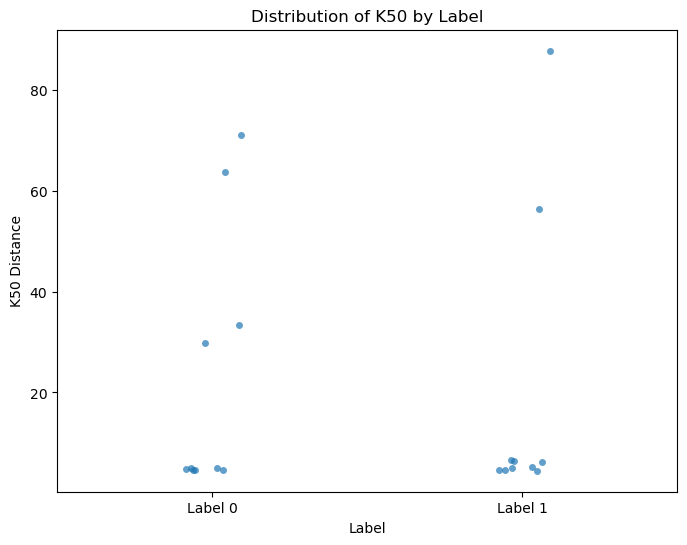

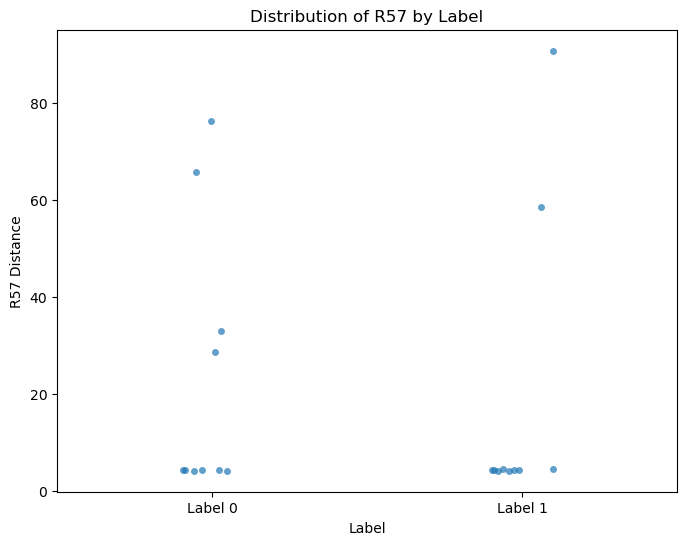

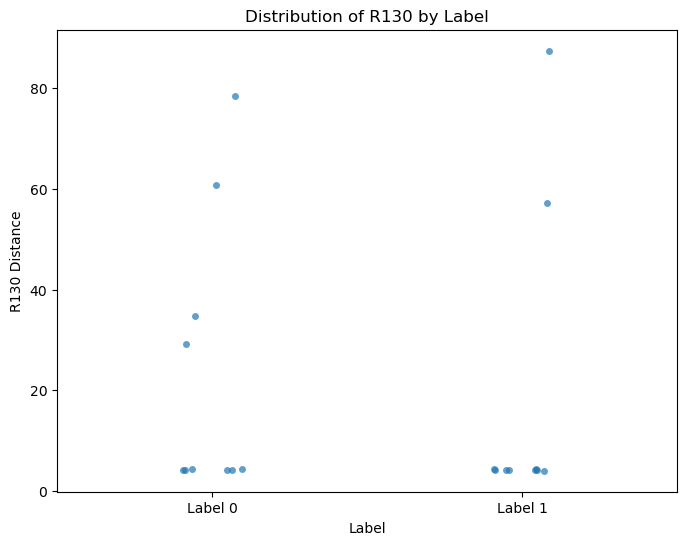

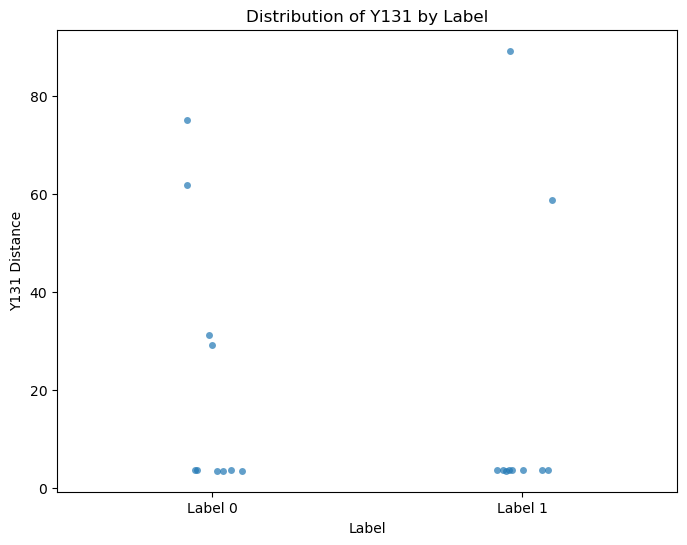

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# Define columns of interest
columns_of_interest = ["K50", "R57", "R130", "Y131"]

# Iterate over each column and plot
for column in columns_of_interest:
    plt.figure(figsize=(8, 6))
    
    # Use stripplot to create a single dot plot with separation
    sns.stripplot(x='label', y=column, data=df, jitter=True, dodge=True, marker='o', alpha=0.7)
    
    plt.title(f'Distribution of {column} by Label')
    plt.xlabel('Label')
    plt.ylabel(f'{column} Distance')
    plt.xticks([0,1], ['Label 0', 'Label 1'])  # Label x-axis for clarity
    
    plt.show()

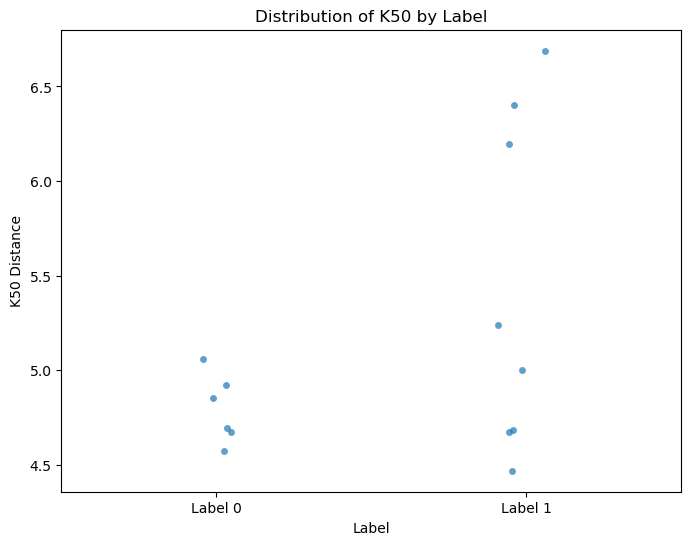

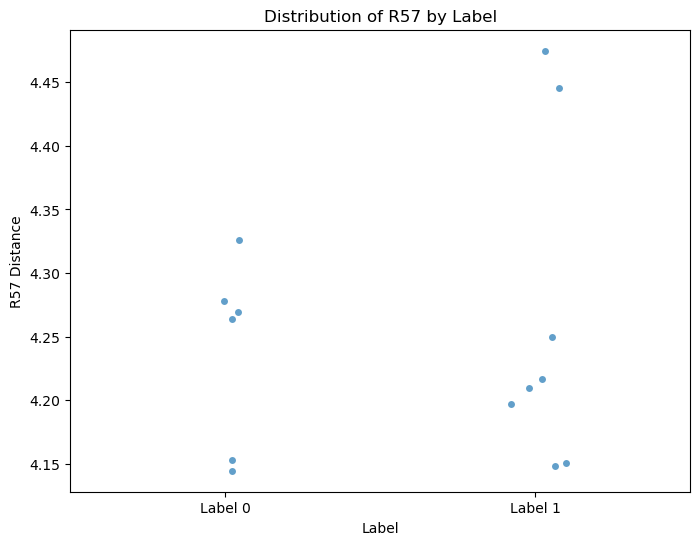

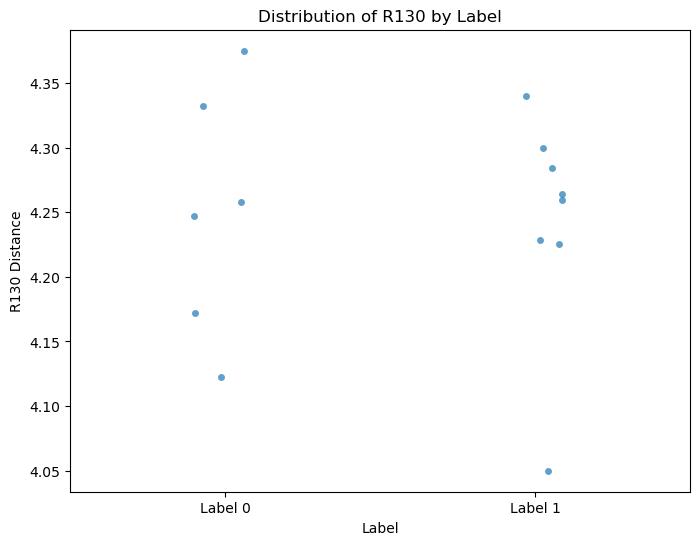

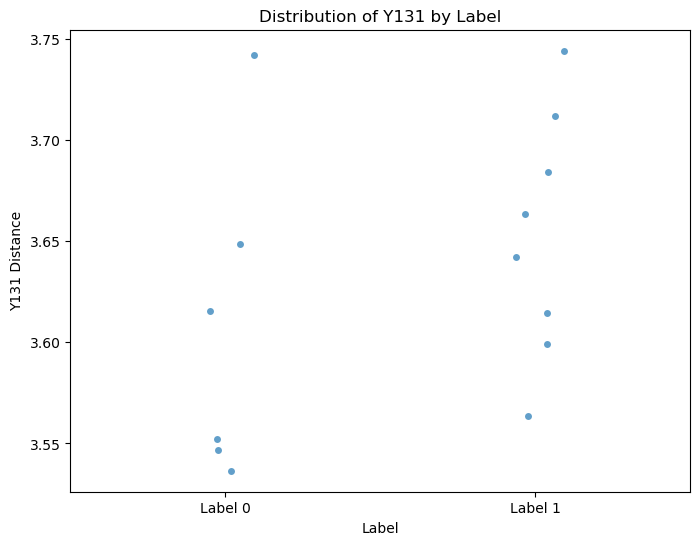

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# Define columns of interest
columns_of_interest = ["K50", "R57", "R130", "Y131"]

# Iterate over each column and plot
for column in columns_of_interest:
    plt.figure(figsize=(8, 6))
    
    # Use stripplot to create a single dot plot with separation
    sns.stripplot(x='label', y=column, data=filtered_df, jitter=True, dodge=True, marker='o', alpha=0.7)
    
    plt.title(f'Distribution of {column} by Label')
    plt.xlabel('Label')
    plt.ylabel(f'{column} Distance')
    plt.xticks([0,1], ['Label 0', 'Label 1'])  # Label x-axis for clarity
    
    plt.show()